# Hi-C data analysis workshop (part 2: cooler interface)

Aurèle Piazza, Romain Bulteau

09/2026

---

## Overview
In this section, we will see how to

 - load `.cool`and `.mcool` files with the [`cooler`](https://cooler.readthedocs.io/en/latest/) python API
 - do basic manipulation and plotting of Hi-C data from cool objects.

Material from this section is adapted from the [cooler docs on visualization](https://cooltools.readthedocs.io/en/latest/notebooks/viz.html).


## Setup

Provide paths/links to the course data below.
We will do this at the start of each notebook. 

When running the notebooks on Google Colab, the data is downloaded and the dependencies (re)installed for each notebook/session, which may take a few minutes.

To start, run the cell below to display the form.

In [1]:
# @title { display-mode: "form" }
import ipywidgets as wgts
from IPython.display import display
from IPython import get_ipython
import os

# defaults
folder1 = "path/to/hicstuff_output/AD281_0.02_subsamp/"
fold1_desc = 'Folder 1 (hicstuff output):'

url1 = "https://sdrive.cnrs.fr/public.php/dav/files/xbqPnPwdEg7WMFd/?accept=zip"
url1_desc = 'URL 1 (hicstuff output):'

outfolder= "outputs/part2"
dependencies = "cooler"


# Form definition
environment_toggle = wgts.ToggleButtons(
  options=['Local Jupyter', 'Google Colab'],
  value='Local Jupyter', description='', disabled=False
  )

input1 = wgts.Text(
  value=folder1, description=fold1_desc, 
  style={'description_width':'200px'},
  layout=wgts.Layout(width='600px')
  )

input3 = wgts.Text(
  value=outfolder, description="Output folder (plots)",
  style={'description_width':'200px'},
  layout=wgts.Layout(width='600px')
  )

submit_button = wgts.Button(
  description="Submit",
  button_style='primary'
  )

output = wgts.Output()

title = wgts.HTML('<h3>Data sources</h3>')
desc = wgts.HTML('<p>Select your environment and specify the paths/URLs</p>')
spacer = wgts.HTML('<br>')

# React components
def on_env_change(change):
  env = change['new']
  if env == 'Google Colab':
    input1.description = url1_desc
    input1.placeholder = url1
    input1.value = url1

  else:
    input1.description = fold1_desc
    input1.placeholder = folder1
    input1.value = folder1


environment_toggle.observe(on_env_change, names='value')

def on_submit(b):
  global hicstuff_output_folder, outfolder
  with output:
    output.clear_output()
    env = environment_toggle.value

    if env == 'Google Colab':
      # 1- Install dependencies -------------------------------------------
      get_ipython().system(f'pip install {dependencies}')
      print('\n\nDependencies installed.')

      # 2- Download data --------------------------------------------------

      url1 = input1.value

      inputdir = "hic_data/"
      os.makedirs(inputdir, exist_ok=True)

      folder1 = f"{inputdir}/AD281_0.02_subsamp/"

      if not os.path.isdir(folder1):
        get_ipython().system(f'wget {url1} -O {inputdir}/f1.zip')
        get_ipython().system(f'unzip {inputdir}/f1.zip -d {inputdir}')
        get_ipython().system(f'rm {inputdir}/f1.zip')

      print(f'\nData downloaded and stored to {inputdir}.')
      print(f'The folder variables have been updated accordingly.')
    
    else:
      folder1 = input1.value
      print(f'Using the local folders provided:\n\t-{folder1}')
    
    hicstuff_output_folder = folder1
    outfolder = input3.value

submit_button.on_click(on_submit)

# Assemble and display
form = wgts.VBox([title, environment_toggle, spacer,
  input1, spacer, input3, spacer,
  submit_button,  output
  ])

display(form)

### Checking dependencies

In [2]:
import cooler
import numpy as np
import os
from matplotlib import pyplot as plt

# version check
print(f"cooler: {cooler.__version__}")
print(f"numpy: {np.__version__}")

cooler: 0.10.3
numpy: 1.26.4



## Sample loading

In [3]:
# path to the 'Cool' folder from the hicstuff pipeline
hcs_folder=f"{hicstuff_output_folder}/Cool/"
hcs_sample="AD281_0.02_subsamp_S288c_DSB_chr3_rDNA_parasplit_q20_v324"

# path to a folder on your drive where files/plots will be saved
outputdir=f"{outfolder}/part2/"
os.makedirs(outputdir, exist_ok=True) # create dir if not exist

# color map for plotting
cmap = plt.get_cmap("YlOrBr")
cmap.set_bad('white')

## Loading a `.cool` file

The hicstuff pipeline we just ran generated two files in the `Cool/` output folder:

 - a cool file, ending with `_1kb.cool`
 - a multicool file, ending with `.mcool` (which we'll use in the next section).

We'll load the cool file using the cooler python API.

In [4]:
# path to the cool file
cool_file=f'{hcs_folder}{hcs_sample}_1kb.cool'

c = cooler.Cooler(cool_file)

print(c)

<Cooler "AD281_0.02_subsamp_S288c_DSB_chr3_rDNA_parasplit_q20_v324_1kb.cool::/">


### Object contents and handling

In [5]:
# print the chr names and bin size
print(f'chromosomes: {c.chromnames}')
print(f'binsize: {c.binsize}')

chromosomes: ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', '2_micron', 'mitochondrion']
binsize: 1000


In [6]:
# print the top-left corner of the matrix
print(c.matrix(balance=False)[0:10,0:10])

[[ 3  3  4  3  1  6  4  1  7  1]
 [ 3  2  8  6  0  2  4  2  2  1]
 [ 4  8  2  5  2  4  7  1  3  0]
 [ 3  6  5  3  3 11  6  1  5  2]
 [ 1  0  2  3  0  4  2  2  5  5]
 [ 6  2  4 11  4  0  4  1  7  5]
 [ 4  4  7  6  2  4  2  4 20  4]
 [ 1  2  1  1  2  1  4  0  5  3]
 [ 7  2  3  5  5  7 20  5 11 11]
 [ 1  1  0  2  5  5  4  3 11  1]]


In [7]:
# fetch the c.matrix coordinates of a chr with c.extent()
print(c.extent("chr5"))

# fetch a specific region
print(c.extent("chr5:120,000-250,000"))

(2892, 3471)
(3012, 3142)


### Simple matrix plotting

0 1360


/tmp/ipykernel_809115/3681097265.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


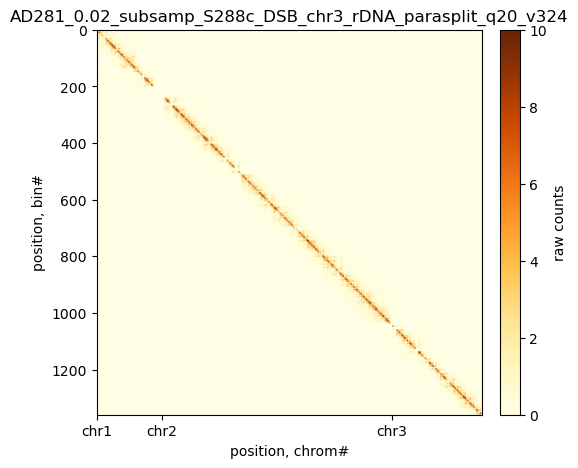

In [8]:
chrs=["chr1", "chr2", "chr3"] # (consecutive) chr to plot

# extract bin indices
exts  = [c.extent(ch) for ch in chrs]
start = np.min(exts)
end   = np.max(exts)

print(start, end)

# create plot area
f, ax = plt.subplots(figsize=(6,5))
# add matrix
im = ax.imshow(c.matrix(balance=False)[start:end, start:end],
               cmap = cmap, vmax=10);
# define axes / labels
ax.set(xticks=[e[0] for e in exts], xticklabels=chrs,
       xlabel='position, chrom#', ylabel='position, bin#')
ax.xaxis.set_label_position('bottom')
ax.set_title(hcs_sample)
# add legend
f.colorbar(im ,fraction=0.046, pad=0.04, label='raw counts')

# save/show
f.savefig(str(outputdir + hcs_sample + '_'.join(chrs) + "_cool_1kb" + ".pdf"), format="pdf", dpi=300)
f.show()

## Loading a `.mcool` file


In [9]:
# path to the mcool file
mcool_file=f'{hcs_folder}{hcs_sample}.mcool'

# list_coolers can be used to print which resolutions are stored in the mcool file
cooler.fileops.list_coolers(mcool_file)

['/resolutions/1000',
 '/resolutions/2000',
 '/resolutions/5000',
 '/resolutions/10000',
 '/resolutions/15000',
 '/resolutions/20000']

In [10]:
# a cooler with a specific resolution can be loaded with:
c = cooler.Cooler(f'{mcool_file}::resolutions/10000')

Check the chromsome names and binsize of the loaded cool

In [11]:
# your code here

In [12]:
# Answer
# to print chromosomes and binsize for this cooler
print(f'chromosomes: {c.chromnames}')
print(f'binsize: {c.binsize}')

chromosomes: ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', '2_micron', 'mitochondrion']
binsize: 10000


<br>

We can plot it using the same code as above

0 137


/tmp/ipykernel_809115/837671552.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


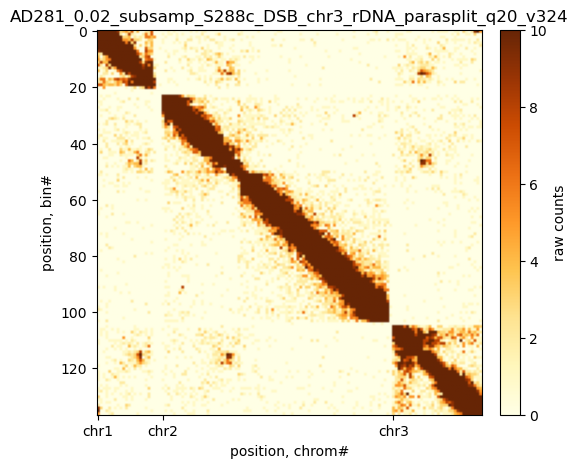

In [13]:
chrs=["chr1", "chr2", "chr3"] # (consecutive) chr to plot

# extract bin indices
exts  = [c.extent(ch) for ch in chrs]
start = np.min(exts)
end   = np.max(exts)

print(start, end)

# create plot area
f, ax = plt.subplots(figsize=(6,5))
# add matrix
im = ax.imshow(c.matrix(balance=False)[start:end, start:end],
               cmap = cmap, vmax=10);
# define axes / labels
ax.set(xticks=[e[0] for e in exts], xticklabels=chrs,
       xlabel='position, chrom#', ylabel='position, bin#')
ax.xaxis.set_label_position('bottom')
ax.set_title(hcs_sample)
# add legend
f.colorbar(im ,fraction=0.046, pad=0.04, label='raw counts')

# save/show
f.savefig(str(outputdir + hcs_sample + '_'.join(chrs) + "mcool_resolution_10kb" + ".pdf"), format="pdf", dpi=300)
f.show()

<br>

We will load and plot all the different resolutions in the mcool file side by side for comparison.

/tmp/ipykernel_809115/534483612.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


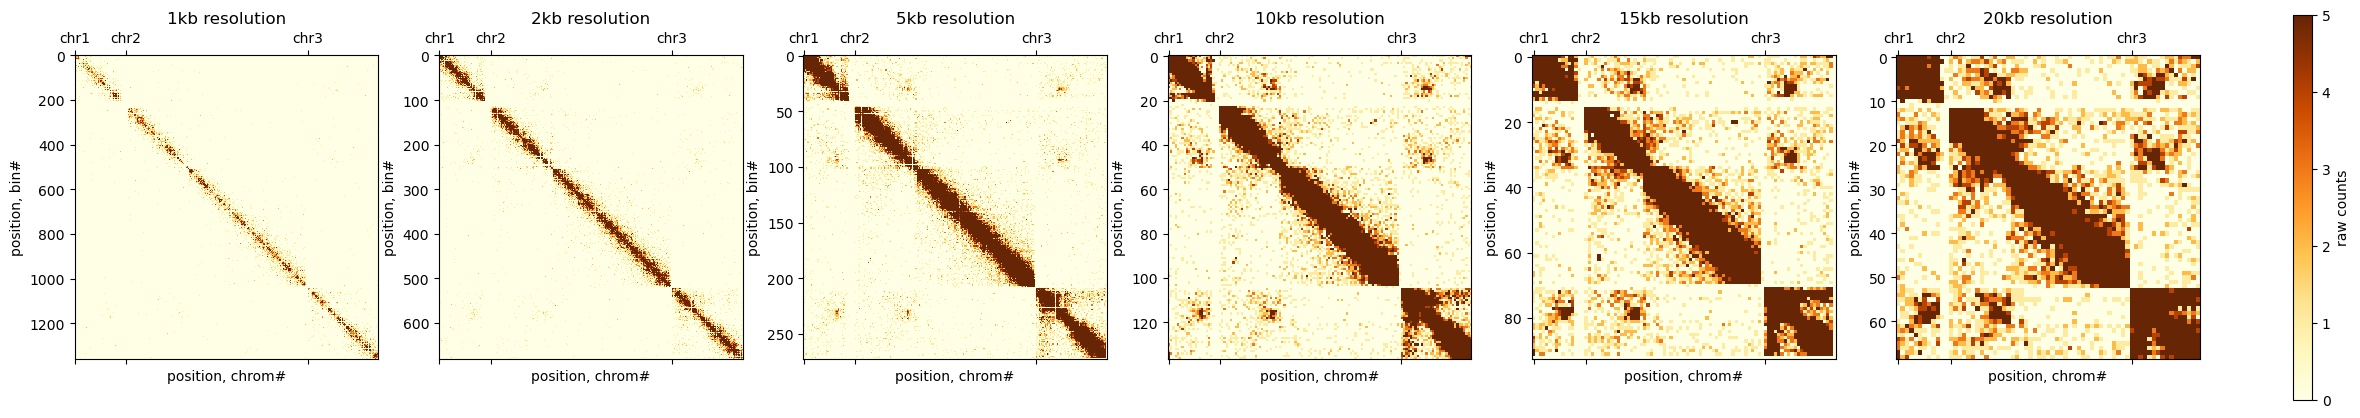

In [14]:
# get list of resolutions in mcool file
res = cooler.fileops.list_coolers(mcool_file)

chrs=["chr1", "chr2", "chr3"] # (consecutive) chr to plot

f,axs = plt.subplots(figsize=(5*len(res),5), ncols=len(res))
for i,r in enumerate(res):
    # load specific resolution
    c = cooler.Cooler(f'{mcool_file}::{r}')

    # extract bin indices
    exts = [c.extent(ch) for ch in chrs]
    start = np.min(exts)
    end   = np.max(exts)

    # plot
    ax = axs[i]
    im = ax.matshow((c.matrix(balance=False)[start:end, start:end]), vmax=5, cmap=cmap);
    ax.set(xticks=[e[0] for e in exts], xticklabels=chrs,
           xlabel='position, chrom#', ylabel='position, bin#')
    ax.xaxis.set_label_position('bottom')
    ax.set_title(f'{int(c.binsize // 1000)}kb resolution')

# add legend
f.colorbar(im, ax=axs,fraction=0.046, pad=0.04, label='raw counts', cmap=cmap)

f.savefig(str(outputdir + hcs_sample + '_'.join(chrs) + "mcool_plot_per_resolution" + ".pdf"), format="pdf", dpi=300)
f.show()

With larger bins, we naturally have more contacts, which saturates the color scale limit set above.

## Normalization and logging

You may have noticed the `balance=False` option in the calls to the cool matrix up to here, e.g.
```py
c.matrix(balance=False)[start:end, start:end]`
```

This retrieves the raw contact counts from the matrix, without normalization steps (e.g. ICE) that may have been performed on the data.

Aside from normalisation, plotting the contact frequency on a log scale also allows for better visualization of the data.

Let's compare our matrix with these different transformations. Note the scale of each color map.


/tmp/ipykernel_809115/4188218978.py:24: RuntimeWarning: divide by zero encountered in log10
  axs[1].imshow(np.log10(c.matrix(balance=False)[start:end, start:end]),
/tmp/ipykernel_809115/4188218978.py:36: RuntimeWarning: divide by zero encountered in log10
  axs[3].imshow(np.log10(c.matrix(balance=True)[start:end, start:end]),
/tmp/ipykernel_809115/4188218978.py:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


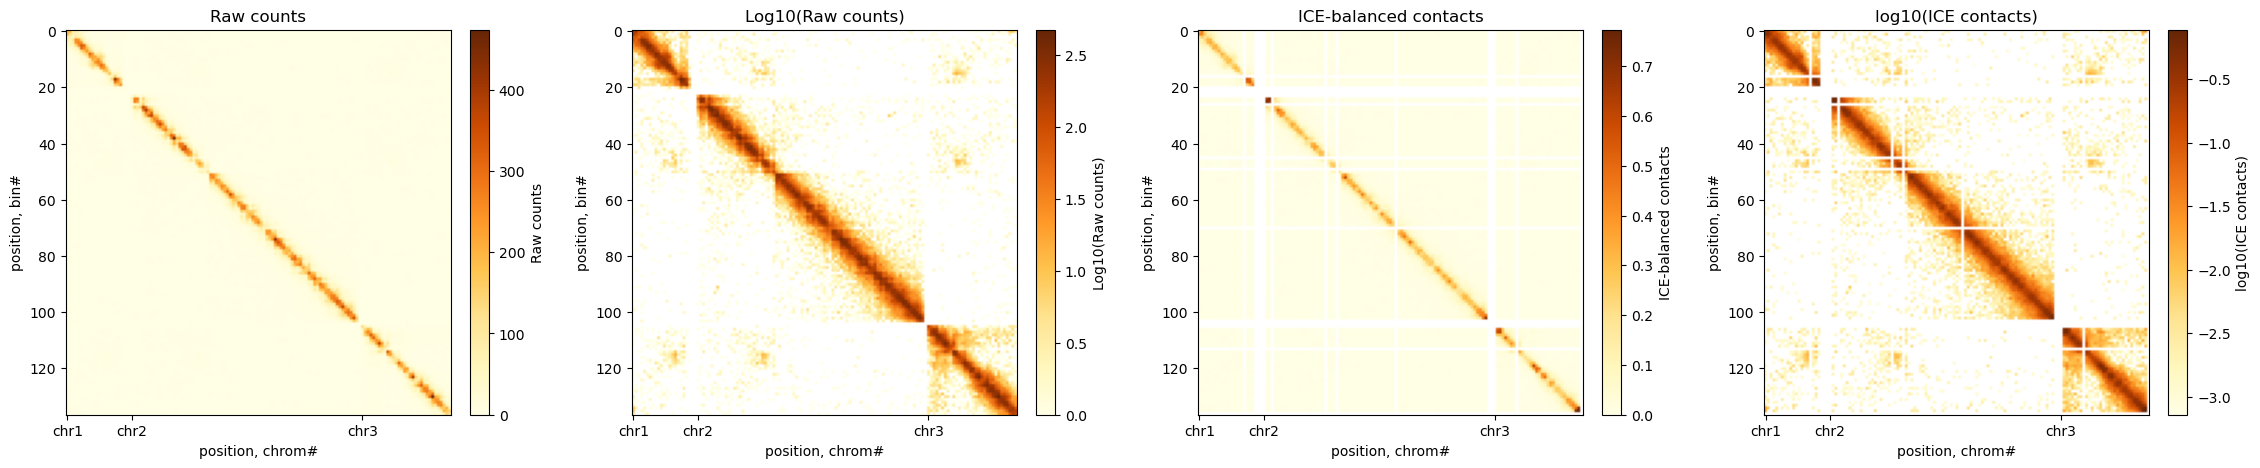

In [15]:
# load cool file at 10kb
c = cooler.Cooler(f'{mcool_file}::resolutions/10000')

# (consecutive) chr to plot
chrs=["chr1", "chr2", "chr3"]

# extract bin indices
exts  = [c.extent(ch) for ch in chrs]
start = np.min(exts)
end   = np.max(exts)

# create plot area
f,axs = plt.subplots(figsize=(4*7,5), ncols=4)
ims = []

# Raw counts
ims.append(
    axs[0].imshow(c.matrix(balance=False)[start:end, start:end],
                  cmap = cmap)#, vmax=20)
)

# Log10 transform
ims.append(
    axs[1].imshow(np.log10(c.matrix(balance=False)[start:end, start:end]),
                  cmap = cmap)#, vmax=np.log10(21))
)

# ICE-normalized
ims.append(
    axs[2].imshow(c.matrix(balance=True)[start:end, start:end],
                  cmap = cmap)
)

# ICE-normalized + Log10 transform
ims.append(
    axs[3].imshow(np.log10(c.matrix(balance=True)[start:end, start:end]),
                  cmap = cmap)
)

labels = ['Raw counts', 'Log10(Raw counts)', 'ICE-balanced contacts', 'log10(ICE contacts)']
# define axes / labels
for i,ax in enumerate(axs):
    ax.set(xticks=[e[0] for e in exts], xticklabels=chrs,
           xlabel='position, chrom#', ylabel='position, bin#')
    ax.xaxis.set_label_position('bottom')
    ax.set_title(labels[i])
    # add legend
    f.colorbar(ims[i] ,fraction=0.046, pad=0.04, label=labels[i])

# save/show
f.savefig(str(outputdir + hcs_sample + '_'.join(chrs) + "_normalization_log_1kb" + ".pdf"), format="pdf", dpi=300)
f.show()


## Bonus:
Plot a log10-normalized Hi-C matrix of all chromosomes in 20kb resolution,

In [16]:
# your code here

/tmp/ipykernel_809115/160424666.py:15: RuntimeWarning: divide by zero encountered in log10
  im = ax.matshow(np.log10(c.matrix(balance=True)[:,:]),
/tmp/ipykernel_809115/160424666.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


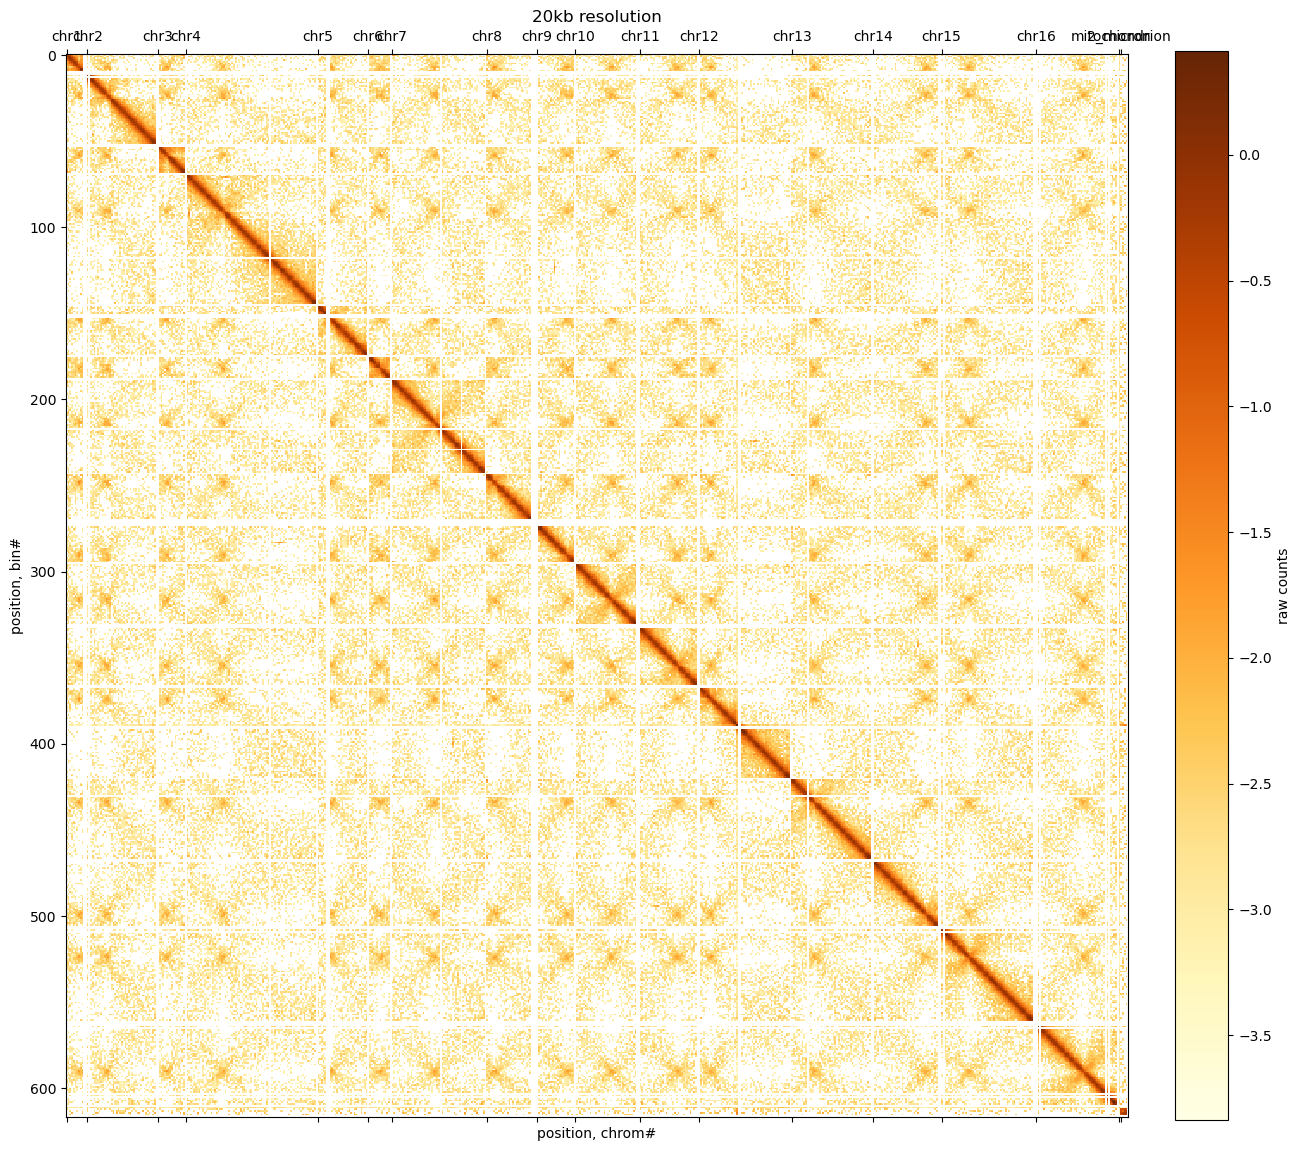

In [17]:
# @title
# Answer

# load 20kb resolution
c = cooler.Cooler(f'{mcool_file}::{res[-1]}')

# fetch chr positions (for labels)
exts = [ c.extent(ch) for ch in c.chromnames ]


# create plot area
f,ax = plt.subplots(figsize=(15,15))

# add matrix
im = ax.matshow(np.log10(c.matrix(balance=True)[:,:]),
                cmap=cmap);
# axes
ax.set(xticks=[e[0] for e in exts], xticklabels=c.chromnames,
       xlabel='position, chrom#', ylabel='position, bin#')
ax.xaxis.set_label_position('bottom')
ax.set_title(f'{int(c.binsize // 1000)}kb resolution')

# add legend
f.colorbar(im, ax=ax,fraction=0.046, pad=0.04, label='raw counts', cmap=cmap)

f.savefig(str(outputdir + hcs_sample + '_'.join(chrs) + f"_full_genome_{int(c.binsize // 1000)}kb" + ".pdf"), format="pdf", dpi=300)
f.show()